# Ý Tưởng:
- Bộ dữ liệu có những mã cổ phiếu đầu tiên xuất hiện từ năm 2012->2026
- Chia bộ dữ liệu làm 3 phần, mỗi phần 4 năm
- Dùng bộ dữ liệu đầu tiên để dự đoán bộ dữ liệu tiếp theo, sau đó tiếp theo dự đoán hiện tại
- Đánh theo dòng tiền 

**Ưu điểm**
- Dễ finetune vì đã xảy ra các kết quả rồi

**Nhược điểm**
- Năm 2012-2017: Là T+3, thanh khoản yếu, nhỏ lẻ ít. Năm 2018- đến nay: Là T+2.5, thanh khoản mạnh
- Năm 2012-2017: Là thời kỳ uptrend cứ volume lớn đặt lệnh là ăn, 2018-2021: Covid19 suy thoái => Khiến cho mô hình tưởng rằng cứ ở đáy đặt volume lớn là ăn
- Bị trễ đi chậm hơn so với thực tế 

**Khắc phục**
- Dùng chỉ số thị trường để xác định cùng
- Thử chuyển sang cửa số trượt động, mỗi quý train lại 3 năm gần nhất => Phù hợp lối đánh hiện nay


**Trước tiên**
- Quy tắc: Dòng tiền => Phân tích kỹ thuật => Thông tin => Quyết định mua/bán

**Các bước làm**
- Thu thập dữ liệu (Done)
- EDA ()
- Xử lý dữ liệu ()
- Xây dựng mô hình ()

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [185]:
df_ck=pd.read_csv("Data/DataCK.csv")
df_ck


,Date,Ticker,Open,High,Low,Close,Volume
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0
...,...,...,...,...,...,...,...
25906,2026-03-13,VRE,25.60,26.00,25.25,25.25,3440100.0
25907,2026-03-16,VRE,25.25,25.90,25.10,25.90,4825600.0
25908,2026-03-17,VRE,26.00,26.90,25.90,26.45,5159000.0
25909,2026-03-18,VRE,26.50,26.95,26.10,26.10,3490200.0


In [186]:
df_ck["Date"]= pd.to_datetime(df_ck["Date"], format="%Y-%m-%d") # Định dạng cào qua api là năm/tháng/ngày

In [187]:
df_ck.info()

<class 'pandas.DataFrame'>
RangeIndex: 25911 entries, 0 to 25910
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    25911 non-null  datetime64[us]
 1   Ticker  25911 non-null  str           
 2   Open    25911 non-null  float64       
 3   High    25911 non-null  float64       
 4   Low     25911 non-null  float64       
 5   Close   25911 non-null  float64       
 6   Volume  25911 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 1.5 MB


In [188]:
df_ck.Date.min()

Timestamp('2021-01-04 00:00:00')

# EDA

### Missing Date

In [189]:
def missing_date(df, date_col="Date", ticker_col="Ticker", output_file="Missing_Dates_Report.csv"):
    df_check= df.copy()
    df_check[date_col]= pd.to_datetime(df_check[date_col])

    calendar= pd.Series(sorted(df_check[date_col].unique()))
    results= []
    missing= []
    for ticker in df_check[ticker_col].unique():
        ticker_data= df_check[df_check[ticker_col] == ticker]
        ticker_dates= set(ticker_data[date_col])

        start_date= ticker_data[date_col].min()
        end_date= ticker_data[date_col].max()

        expected= set(calendar[(calendar>= start_date) & (calendar<= end_date)])
        missing_dates= expected - ticker_dates
        
        if missing_dates:
            results.append({
                "Ticker": ticker,
                "Missing_Days_Count": len(missing_dates)
            })
            for d in missing_dates:
                missing.append({
                    "Ticker": ticker,
                    "Missing_Date": d.strftime("%Y-%m-%d")
                })

    if missing:
        summary_df= pd.DataFrame(results).sort_values(by="Missing_Days_Count", ascending=False)
        details_df= pd.DataFrame(missing).sort_values(by=["Ticker", "Missing_Date"])
        details_df.to_csv(output_file, index=False)
        print(f"Đã lưu ra file:{output_file}")
    else:
        summary_df = pd.DataFrame(columns=["Ticker", "Missing_Days_Count"])
        details_df = pd.DataFrame(columns=["Ticker", "Missing_Date"])
        print("Không thiếu ngày nào")
    return summary_df, details_df

summary, details= missing_date(df_ck, output_file="Missing_Dates_Report.csv")
if not summary.empty:
    display(summary)

Đã lưu ra file:Missing_Dates_Report.csv


,Ticker,Missing_Days_Count
0,BSR,8
1,VN30F1M,1


**Nhận Xét**
- BSR thiếu 8 ngày vào năm 2025 giai đoạn tháng 1 vì lúc này vừa chuyển từ sàn UPCOM sang HOSE
- VN30F1M thiếu ngày 2023-04-07

### Process VNINDEX and VN30

In [190]:
df_vnindex= pd.read_excel("Data/LichSuGia_VNINDEX_01_01_2021_03_19_2026.xlsx")
df_vnindex.head()

,Ngay,GiaDieuChinh,GiaDongCua,ThayDoi,KhoiLuongKhopLenh,GiaTriKhopLenh,KLThoaThuan,GtThoaThuan,GiaMoCua,GiaCaoNhat,GiaThapNhat
0,18/03/2026,"1713,83","1713,83","3,54(0,21 %)",698898800,21562750660000,129156598,3140468907500,"1718,3","1742,87","1703,4"
1,17/03/2026,"1710,29","1710,29","17,08(1,01 %)",724341700,7243417000000,148583440,3500824249450,"1709,38","1732,31","1707,5"
2,16/03/2026,"1693,21","1693,21","-3,03(-0,18 %)",745318200,20307816450000,123251364,2594949056180,"1701,06",1707,"1680,7"
3,13/03/2026,"1696,24","1696,24","-13,37(-0,78 %)",876840300,24701434140000,144178661,2659800839800,"1697,72","1716,75","1688,67"
4,12/03/2026,"1709,61","1709,61","-18,73(-1,08 %)",856853300,24424934290000,87959608,1883759307800,"1716,62","1725,52","1701,59"


In [191]:
df_vnindex.info()

<class 'pandas.DataFrame'>
RangeIndex: 1293 entries, 0 to 1292
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Ngay               1293 non-null   str  
 1   GiaDieuChinh       1293 non-null   str  
 2   GiaDongCua         1293 non-null   str  
 3   ThayDoi            1293 non-null   str  
 4   KhoiLuongKhopLenh  1293 non-null   int64
 5   GiaTriKhopLenh     1293 non-null   int64
 6   KLThoaThuan        1293 non-null   int64
 7   GtThoaThuan        1293 non-null   int64
 8   GiaMoCua           1293 non-null   str  
 9   GiaCaoNhat         1293 non-null   str  
 10  GiaThapNhat        1293 non-null   str  
dtypes: int64(4), str(7)
memory usage: 183.8 KB


In [192]:
def process(file_path, ticker):
    df= pd.read_excel(file_path)
    cols_to_keep= ["Ngay", "GiaMoCua", "GiaCaoNhat", "GiaThapNhat", "GiaDongCua", "KhoiLuongKhopLenh"]
    df= df[cols_to_keep].copy()
    df.columns= ["Date", "Open", "High", "Low", "Close", "Volume"]
    num_cols= ["Open", "High", "Low", "Close", "Volume"]
    for col in num_cols:
        df[col]= df[col].astype(str).str.replace(',', '.')
        df[col]= pd.to_numeric(df[col], errors="coerce")

    df["Date"]= pd.to_datetime(df["Date"], format="mixed", dayfirst=True) # Định dạng excel là ngày/tháng/năm
    df["Ticker"]= ticker
    df= df[["Date", "Ticker", "Open", "High", "Low", "Close", "Volume"]]
    df= df.sort_values("Date").reset_index(drop=True)
    return df

file_vnindex= "Data/LichSuGia_VNINDEX_01_01_2021_03_19_2026.xlsx"
file_vn30= "Data/LichSuGia_VN30INDEX_01_01_2021_03_19_2026.xlsx"

df_vnindex= process(file_vnindex, "VNINDEX")
df_vn30= process(file_vn30, "VN30")

print(df_vnindex.info())

<class 'pandas.DataFrame'>
RangeIndex: 1293 entries, 0 to 1292
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1293 non-null   datetime64[us]
 1   Ticker  1293 non-null   str           
 2   Open    1293 non-null   float64       
 3   High    1293 non-null   float64       
 4   Low     1293 non-null   float64       
 5   Close   1293 non-null   float64       
 6   Volume  1293 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 79.8 KB
None


In [193]:
df_concat= pd.concat([df_vnindex, df_vn30], ignore_index=True)
df_concat.info()

<class 'pandas.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2587 non-null   datetime64[us]
 1   Ticker  2587 non-null   str           
 2   Open    2587 non-null   float64       
 3   High    2587 non-null   float64       
 4   Low     2587 non-null   float64       
 5   Close   2587 non-null   float64       
 6   Volume  2587 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 155.8 KB


In [194]:
summary, details= missing_date(df_concat, output_file="Missing_Dates_Report1.csv")
if not summary.empty:
    display(summary)

Đã lưu ra file:Missing_Dates_Report1.csv


,Ticker,Missing_Days_Count
0,VNINDEX,1


**Nhận Xét**
- VNINDEX thiếu 1 ngày 2024-05-17

### Gộp 2 bảng dữ liệu lại

In [195]:
df_all= pd.concat([df_ck, df_concat], ignore_index=True)
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 28498 entries, 0 to 28497
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    28498 non-null  datetime64[us]
 1   Ticker  28498 non-null  str           
 2   Open    28498 non-null  float64       
 3   High    28498 non-null  float64       
 4   Low     28498 non-null  float64       
 5   Close   28498 non-null  float64       
 6   Volume  28498 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 1.6 MB


### Gaps Days
- Có thê thấy Date không liền mạch vì thị trường nghỉ vào thứ 7 và chủ nhật. Thêm nữa là nghỉ vào những ngày lễ. 
- Không được xử lý những ngày này

In [196]:
dates_series= pd.Series(sorted(df_all.Date.unique()))
dates_series

0      2021-01-04
1      2021-01-05
2      2021-01-06
3      2021-01-07
4      2021-01-08
          ...    
1291   2026-03-13
1292   2026-03-16
1293   2026-03-17
1294   2026-03-18
1295   2026-03-19
Length: 1296, dtype: datetime64[us]

In [197]:
gaps_day= dates_series.diff().dt.days-1
gaps_day

0       NaN
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
1291    0.0
1292    2.0
1293    0.0
1294    0.0
1295    0.0
Length: 1296, dtype: float64

In [198]:
gaps_df= pd.DataFrame(
    {
        "previous_day": dates_series.shift(1),
        "next_days": dates_series,
        "gaps_days": gaps_day
    }
)
gaps_df

,previous_day,next_days,gaps_days
0,NaT,2021-01-04,NaN
1,2021-01-04,2021-01-05,0.0
2,2021-01-05,2021-01-06,0.0
3,2021-01-06,2021-01-07,0.0
4,2021-01-07,2021-01-08,0.0
...,...,...,...
1291,2026-03-12,2026-03-13,0.0
1292,2026-03-13,2026-03-16,2.0
1293,2026-03-16,2026-03-17,0.0
1294,2026-03-17,2026-03-18,0.0


In [199]:
gaps_df[gaps_df.gaps_days>=1]

,previous_day,next_days,gaps_days
5,2021-01-08,2021-01-11,2.0
10,2021-01-15,2021-01-18,2.0
15,2021-01-22,2021-01-25,2.0
20,2021-01-29,2021-02-01,2.0
25,2021-02-05,2021-02-08,2.0
...,...,...,...
1272,2026-02-06,2026-02-09,2.0
1277,2026-02-13,2026-02-23,9.0
1282,2026-02-27,2026-03-02,2.0
1287,2026-03-06,2026-03-09,2.0


- 2026-02-13->2026-02-23: Kì nghỉ tết Nguyên Đán

In [200]:
gaps_df[gaps_df.gaps_days==1]

,previous_day,next_days,gaps_days
72,2021-04-20,2021-04-22,1.0
820,2024-04-17,2024-04-19,1.0
998,2024-12-31,2025-01-02,1.0


2021-04-20->2021-04-22: Ngày Dỗ Tổ Hùng Vương

### Price and Volume

In [201]:
df_all.Ticker.unique()

<ArrowStringArray>
[    'BID',     'BSR',     'CTG',     'FPT',     'GAS',     'GMD',     'HPG',
     'MBB',     'MSR',     'OIL',     'PLX',     'STB',     'TCB',     'VCB',
     'VHM',     'VIC', 'VN30F1M',     'VNM',     'VPB',     'VRE', 'VNINDEX',
    'VN30']
Length: 22, dtype: str

In [202]:
market= ["VNINDEX", "VN30", "VN30F1M"]
df_stock= df_all[~df_all["Ticker"].isin(market)]
df_market= df_all[df_all["Ticker"].isin(market)]
print(df_stock.Ticker.unique())
print(df_market.Ticker.unique())

<ArrowStringArray>
['BID', 'BSR', 'CTG', 'FPT', 'GAS', 'GMD', 'HPG', 'MBB', 'MSR', 'OIL', 'PLX',
 'STB', 'TCB', 'VCB', 'VHM', 'VIC', 'VNM', 'VPB', 'VRE']
Length: 19, dtype: str
<ArrowStringArray>
['VN30F1M', 'VNINDEX', 'VN30']
Length: 3, dtype: str


In [203]:
blue_chips= ["HPG", "BSR", "VIC", "FPT", "TCB","MBB"]
bluechips_df= df_stock[df_stock.Ticker.isin(blue_chips)]
bluechips_df

,Date,Ticker,Open,High,Low,Close,Volume
1296,2021-01-04,BSR,5.60,5.76,5.55,5.72,7327963.0
1297,2021-01-05,BSR,5.66,5.66,5.55,5.60,7046670.0
1298,2021-01-06,BSR,5.66,5.99,5.66,5.83,11445066.0
1299,2021-01-07,BSR,5.88,6.11,5.76,6.11,14177972.0
1300,2021-01-08,BSR,6.11,6.44,5.99,6.39,9549600.0
...,...,...,...,...,...,...,...
20723,2026-03-13,VIC,143.90,148.00,141.20,144.60,2665200.0
20724,2026-03-16,VIC,146.20,147.60,141.40,144.70,2480300.0
20725,2026-03-17,VIC,145.00,150.90,145.00,146.20,2810700.0
20726,2026-03-18,VIC,148.30,156.00,146.00,146.00,4966200.0


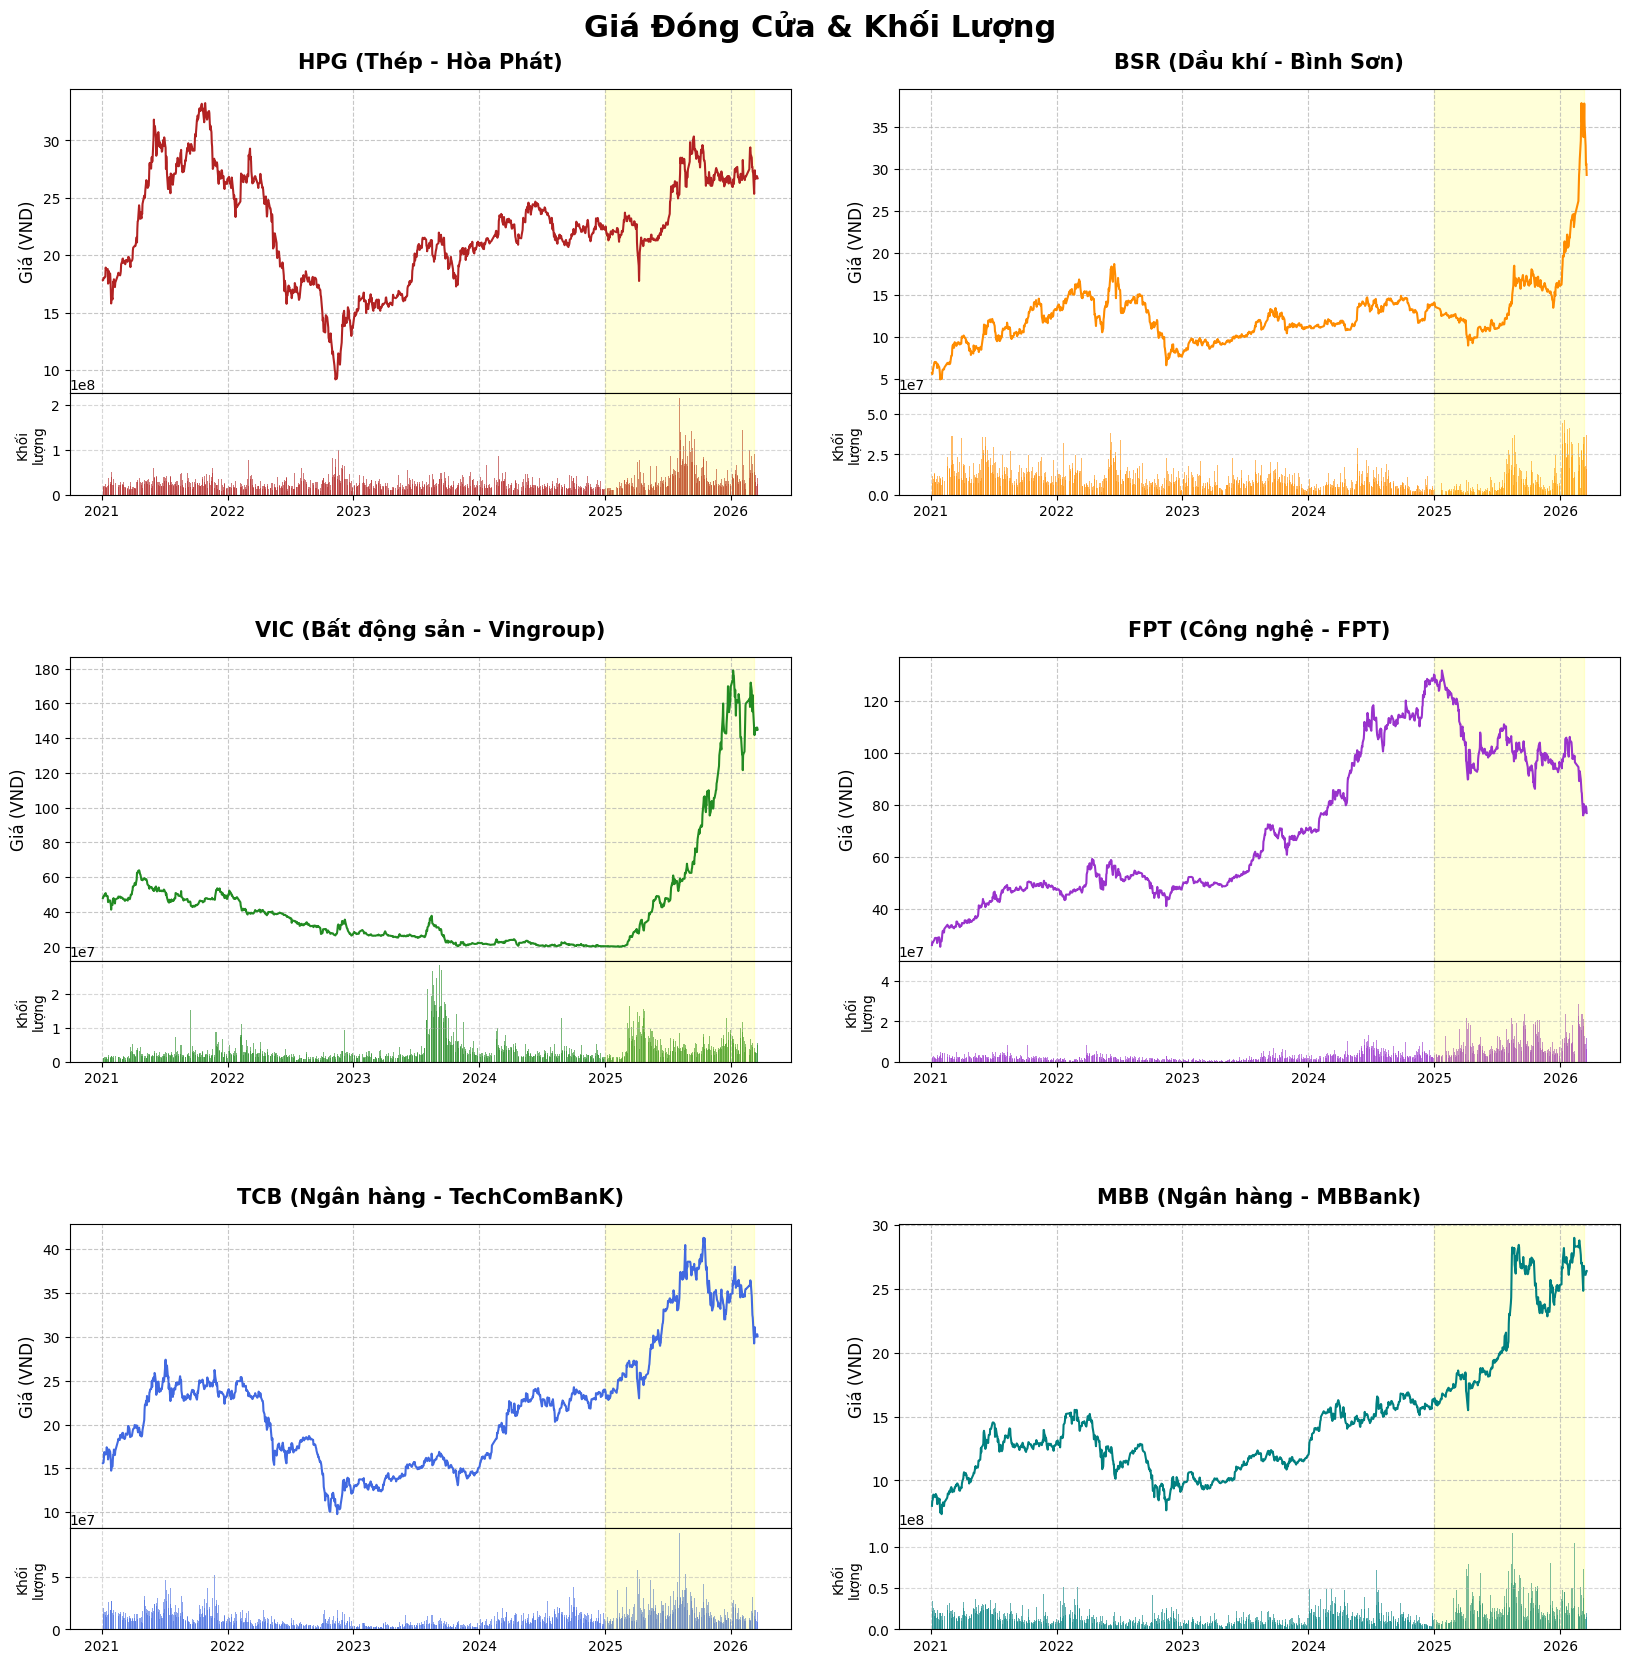

In [204]:
fig= plt.figure(figsize=(20, 20)) 
fig.suptitle("Giá Đóng Cửa & Khối Lượng", fontsize=22, fontweight="bold", y=0.92)

outer_gs= gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.15)
colors= ["firebrick", "darkorange", "forestgreen", "darkorchid", "royalblue", "teal"]
titles= [
    "HPG (Thép - Hòa Phát)", "BSR (Dầu khí - Bình Sơn)", 
    "VIC (Bất động sản - Vingroup)", "FPT (Công nghệ - FPT)", 
    "TCB (Ngân hàng - TechComBanK)", "MBB (Ngân hàng - MBBank)"
]
blue_chips = ["HPG", "BSR", "VIC", "FPT", "TCB", "MBB"]

for i, ticker in enumerate(blue_chips):
    row= i // 2
    col= i % 2
    data= bluechips_df[bluechips_df["Ticker"] == ticker]
    
    inner_gs= gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row, col], height_ratios=[3, 1], hspace=0.0)
    
    ax_price= fig.add_subplot(inner_gs[0])
    ax_price.plot(data["Date"], data["Close"], color=colors[i], linewidth=1.5)
    
    ax_price.axvspan(pd.to_datetime("2025-01-01"), pd.to_datetime("2026-03-10"), color="yellow", alpha=0.15)
    
    ax_price.set_title(titles[i], fontsize=15, fontweight="bold", pad=15)
    ax_price.set_ylabel("Giá (VND)", fontsize=12)
    ax_price.grid(True, linestyle="--", alpha=0.7)
    
    plt.setp(ax_price.get_xticklabels(), visible=False) 
    
    ax_vol= fig.add_subplot(inner_gs[1], sharex=ax_price)
    ax_vol.bar(data["Date"], data["Volume"], color=colors[i], alpha=0.6, width=2)
    
    ax_vol.axvspan(pd.to_datetime("2025-01-01"), pd.to_datetime("2026-03-10"), color="yellow", alpha=0.15)
    
    ax_vol.set_ylabel('Khối\nlượng', fontsize=10) 
    ax_vol.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Nhận Xét**
* Năm 2025:
    - Năm của các sóng ngành Bất Động Sản, Ngân Hàng: 
        + Do sự thông qua và chính thức đi vào thực tiễn của Luật Đất đai (sửa đổi), Luật Nhà ở và Luật Kinh doanh Bất động sản
        + Yếu tố toàn cầu: Do FED hạ lãi suất và nới lỏng chính sách tiền tệ, 
        + Ngân hàng và Bất động sản liên quan mật thiết đến nhau: Hơn  70% tài sản thế chấp ngân hàng là Bất động sản
        => Đây cũng có thể là nguy cơ bong bóng bất động sản ( Vì liên tục được thế chấp tài sản và vay liên tục ) => Không đủ khả năng mua

* Năm 2026:
    - Bắt đầu là sóng dầu khí, trong khi sóng năm 2025 là kết thúc (Cổ phiếu đã bị phân phối) sau đó cổ phiếu tụt dốc không phanh
    - Công nghệ FPT liên tục bị rớt giá. Do có tin đồn rằng có AI thay thế được nhân lực FPT
    

### Phân tích tính mùa vụ

In [205]:
# Lọc ra ngày bắt đầu để xuất phát chung
start= bluechips_df.groupby("Ticker")["Date"].min().max()
print(start)
all_start= bluechips_df[bluechips_df.Date>=start].copy()
all_start

2021-01-04 00:00:00


,Date,Ticker,Open,High,Low,Close,Volume
1296,2021-01-04,BSR,5.60,5.76,5.55,5.72,7327963.0
1297,2021-01-05,BSR,5.66,5.66,5.55,5.60,7046670.0
1298,2021-01-06,BSR,5.66,5.99,5.66,5.83,11445066.0
1299,2021-01-07,BSR,5.88,6.11,5.76,6.11,14177972.0
1300,2021-01-08,BSR,6.11,6.44,5.99,6.39,9549600.0
...,...,...,...,...,...,...,...
20723,2026-03-13,VIC,143.90,148.00,141.20,144.60,2665200.0
20724,2026-03-16,VIC,146.20,147.60,141.40,144.70,2480300.0
20725,2026-03-17,VIC,145.00,150.90,145.00,146.20,2810700.0
20726,2026-03-18,VIC,148.30,156.00,146.00,146.00,4966200.0


In [206]:
all_start["Pct_Change"]= all_start.groupby("Ticker")["Close"].pct_change()
all_start["Month"]= all_start.Date.dt.month
all_start

,Date,Ticker,Open,High,Low,Close,Volume,Pct_Change,Month
1296,2021-01-04,BSR,5.60,5.76,5.55,5.72,7327963.0,NaN,1
1297,2021-01-05,BSR,5.66,5.66,5.55,5.60,7046670.0,-0.020979,1
1298,2021-01-06,BSR,5.66,5.99,5.66,5.83,11445066.0,0.041071,1
1299,2021-01-07,BSR,5.88,6.11,5.76,6.11,14177972.0,0.048027,1
1300,2021-01-08,BSR,6.11,6.44,5.99,6.39,9549600.0,0.045827,1
...,...,...,...,...,...,...,...,...,...
20723,2026-03-13,VIC,143.90,148.00,141.20,144.60,2665200.0,-0.002759,3
20724,2026-03-16,VIC,146.20,147.60,141.40,144.70,2480300.0,0.000692,3
20725,2026-03-17,VIC,145.00,150.90,145.00,146.20,2810700.0,0.010366,3
20726,2026-03-18,VIC,148.30,156.00,146.00,146.00,4966200.0,-0.001368,3


In [207]:
# trung bình tỷ suất sinh lời theo tháng
profitable= all_start.groupby(["Ticker", "Month"])["Pct_Change"].mean().reset_index()
profitable["Return_pct"]= profitable["Pct_Change"]*100
profitable

,Ticker,Month,Pct_Change,Return_pct
0,BSR,1,0.004908,0.490781
1,BSR,2,0.007388,0.738757
2,BSR,3,0.001317,0.131690
3,BSR,4,-0.005102,-0.510191
4,BSR,5,0.007599,0.759901
...,...,...,...,...
67,VIC,8,0.003419,0.341905
68,VIC,9,-0.002143,-0.214299
69,VIC,10,0.000492,0.049179
70,VIC,11,0.006188,0.618842


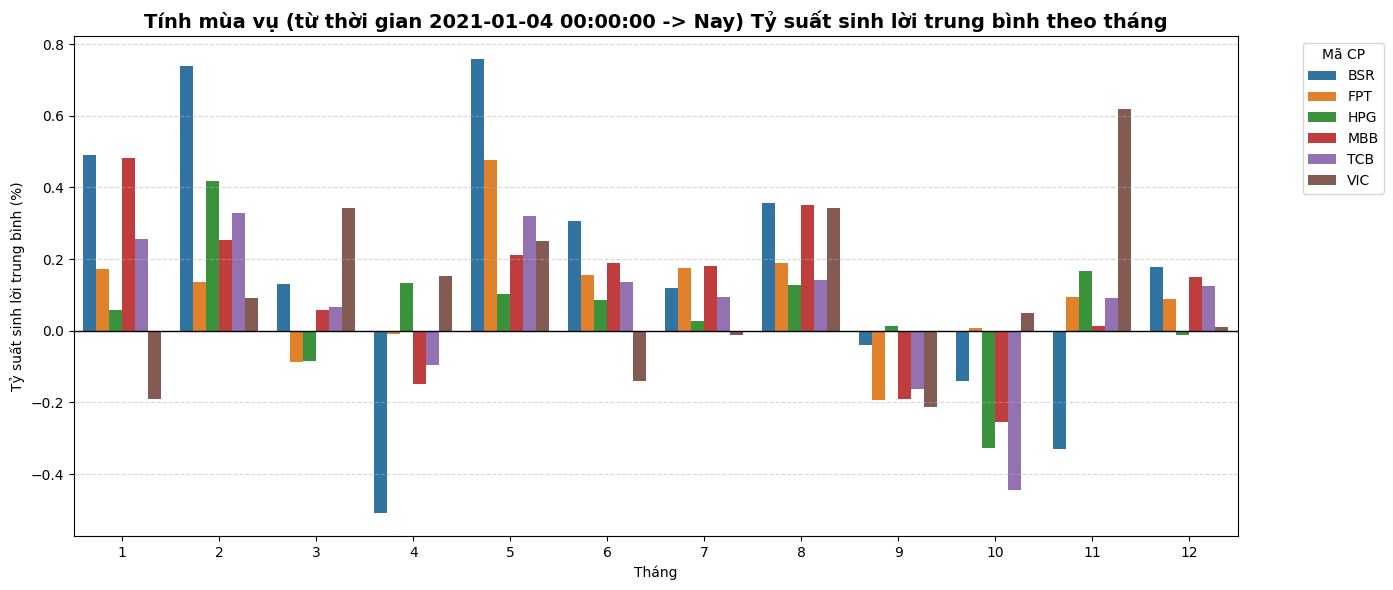

In [208]:
plt.figure(figsize=(14, 6))
sns.barplot(data=profitable, x="Month", y="Return_pct", hue="Ticker")
plt.title(f"Tính mùa vụ (từ thời gian {start} -> Nay) Tỷ suất sinh lời trung bình theo tháng", fontsize=14, fontweight="bold")
plt.ylabel("Tỷ suất sinh lời trung bình (%)")
plt.xlabel("Tháng")
plt.axhline(0, color="black", linewidth=1)
plt.legend(title="Mã CP", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

**Nhận Xét**
- Có thể thấy tỷ suất sinh lời cao nhất vào tháng 1-2. Do bắt đầu vào năm mới ngân hàng và quỹ sẽ giải ngân cho năm mới. Nhà đầu tư sẽ phấn khởi và mua vào
- Đến tháng 3-4 tỷ suất sinh lời bị âm. Do đây là mùa báo cáo tài chính quý 1, họp đại hội cổ đông cũng đã xong. Nhà đầu tư có xu hướng nghỉ dài. Lực cầu yếu
- Tháng 5 là mùa chia cổ tức của các doanh nghiệp lớn như HPG nên dòng tiền đẩy giá lên cao
- Tháng 6-7 sau khi chia cổ tức xong, dòng tiền chốt lời và rút ra. Thêm nữa tháng 7 là đang chờ đợi báo cáo tài chính quý 2, thị trường rơi vào trống thông tin, thanh khoản ít
- Tháng 8 tỷ suất sinh lời vọt lên cao vì báo cáo tài chính quý 2 bắt buộc phải có Kiểm toán độc lập tham gia. Doanh nghiệp nào làm ăn thật và có lãi thì dòng tiền lớn mới quay lại giải ngân để đánh sóng cuối năm
- Tháng 10 tỷ suất sinh lời âm nhiều nhất vì trong lịch sử hay xảy ra các tin tức vĩ mô bất lợi hoặc thanh lọc thị trường gây lên tâm lí hoảng loạn và kích hoạt các đợt bán tháo của nhà đầu tư 

![image.png](images/BCTC.png)

### Mối quan hệ giữa thị trường Phái sinh và thị trường Cơ sở
- VNINDEX: Nơi chúng ta mua bán cổ phiếu gọi là thị trường Cơ sở (T+2.5)
- VN30: Là điểm số đại diện cho 30 công ty vốn hóa lớn nhất, thanh khoản cao nhất trên thị trường cơ sở. Còn được gọi là cổ phiếu Trụ
- VN30F1M: Nơi nhà đầu tư không mua bán thật mà là nơi đặt cược tăng hay giảm vào việc chỉ số VN30 sẽ như thế nào trong tương lai (T+0). Đặc biệt hơn hợp đồng phái sinh bắt buộc phải đáo hạn vào thứ Năm tuần thứ 3 của tháng

**Vào lúc 14h45 ngày Đáo hạn, Giá Phái sinh BẮT BUỘC phải bằng chính xác Điểm số Cơ sở VN30**

- Hiểu đơn giản là thị trường Phái sinh sẽ liên tục đuổi theo VN30 mà VN30 thuộc thị trường cơ sở
- Điều này dễ xảy ra hiện tượng thao túng thị trường Phái sinh
    + Ví dụ: Cá mập họ mở nhiều lênh Long bên thị trường Phái sinh, sau đó họ sang bên thị trường Cơ sở đặt mua những mã cổ phiếu Trụ, kéo nó lên trần. Điều này khiến VN30 tăng điểm, họ sẽ đóng lệnh bên Long bên Phái sinh và chốt lãi
    + Ngược lại với lệnh Short, họ sẽ mang những mã cổ phiếu Trụ ra bán tháo (thường là sau 14h). Sẽ khiến VN30 sập xuống

=> Hiện tượng này gọi là "Sự trả điểm". Sau khi thực hiện xong (ngừng bơm tiền / ngừng xả hàng) thị trường sẽ lại quay về như lúc ban đầu

- Bản chất của lệnh Short đó là Long: Tức là đặt lệnh Short (tin thị trường xuống) thì sẽ bán hợp đồng  với người đặt lệnh Long (tin thị trường lên). Nếu thị trường xuống thật, muốn chốt lãi cần phải MUA hợp đồng từ một người nào đó đang muốn BÁN ra trên thị trường


In [209]:
table_market= df_market.pivot_table(index="Date", columns="Ticker", values="Close").dropna()
table_market

Ticker,VN30,VN30F1M,VNINDEX
Date,,,
2021-01-04,1091.87,1109.4,1120.47
2021-01-05,1104.30,1111.0,1132.55
2021-01-06,1113.72,1125.0,1143.21
2021-01-07,1130.59,1148.9,1156.49
2021-01-08,1147.86,1176.6,1167.69
...,...,...,...
2026-03-12,1859.80,1853.0,1709.61
2026-03-13,1853.60,1840.0,1696.24
2026-03-16,1852.99,1851.3,1693.21


- Basis = Giá Phái sinh (VN30F) - Điểm số VN30
    + Basis Dương: Thể hiện tâm lí lạc quan thị trường sẵn sàng trả giá cao. Tuy nhiên nếu Basis quá lớn (>10 điểm). Cá mập sẽ bán khống (Short) Phái sinh và mua Cơ sở để ăn chênh lệch
        - Ví dụ: Điểm Cơ sở (VN30) đang là 1200, do hưng phấn nên đua nhau cược tăng giá phái sinh bị đẩy lên 1220 -> Basis tăng 20 điểm. Cá mập sẽ bán (Short) Phái sinh ở mức 1220 điểm và bỏ tiền mua Cổ phiếu trong VN30 ở mức 1200
        * Trường hợp A: Thị trường sập về (1100): Cổ phiếu lỗ (100 điểm) nhưng lệnh Short phái sinh lãi (120 điểm) -> 120-100=20
        * Trường hợp B: Thị trường tăng lên (1300): Lệnh Short lỗ (80 điểm) nhưng Cổ phiếu lãi (100 điểm) -> 100-80=20


    + Basis Âm: Thể hiện tâm lí bi quan, sợ hãi thị trường sập. Nếu Basis quá âm (<-15 điểm) thường thị trường Cơ sở sẽ bị đạp mạnh để bắt kịp sự bi quan của Phái sinh

In [210]:
table_market["Basis"]= table_market["VN30F1M"]- table_market["VN30"]
table_market["T_1"]= table_market["VN30"].pct_change().shift(-1)*100
table_market["T_2"]= table_market["VN30"].pct_change(periods=2).shift(-2)*100
table_market

Ticker,VN30,VN30F1M,VNINDEX,Basis,T_1,T_2
Date,,,,,,
2021-01-04,1091.87,1109.4,1120.47,17.53,1.138414,2.001154
2021-01-05,1104.30,1111.0,1132.55,6.70,0.853029,2.380694
2021-01-06,1113.72,1125.0,1143.21,11.28,1.514743,3.065402
2021-01-07,1130.59,1148.9,1156.49,18.31,1.527521,2.902025
2021-01-08,1147.86,1176.6,1167.69,28.74,1.353824,1.844302
...,...,...,...,...,...,...
2026-03-12,1859.80,1853.0,1709.61,-6.80,-0.333369,-0.366168
2026-03-13,1853.60,1840.0,1696.24,-13.60,-0.032909,1.081679
2026-03-16,1852.99,1851.3,1693.21,-1.69,1.114955,0.855374


In [211]:
def category_Basis(Basis):
    if Basis< -10: return "1. Âm Nặng (< -10)"
    elif -10<= Basis< -5: return "2. Âm Nhẹ (-10 đến -5)"
    elif -5<= Basis<= 5: return "3. Bình Thường (-5 đến 5)"
    elif 5< Basis<= 10: return "4. Dương Nhẹ (5 đến 10)"
    else: return "5. Dương Nặng (> 10)"

table_market["Category_Basis"]= table_market["Basis"].apply(category_Basis)

In [212]:
# Nhóm các ngày có cùng trạng thái Basis để xem xác suất T+ tăng hay giảm 
check_basis= table_market.groupby("Category_Basis")[["T_1", "T_2"]].mean().reset_index()
check_basis

Ticker,Category_Basis,T_1,T_2
0,1. Âm Nặng (< -10),-0.397885,-0.264957
1,2. Âm Nhẹ (-10 đến -5),-0.152357,-0.186491
2,3. Bình Thường (-5 đến 5),-0.032538,0.092770
3,4. Dương Nhẹ (5 đến 10),0.232879,0.176510
4,5. Dương Nặng (> 10),51.702438,51.779534


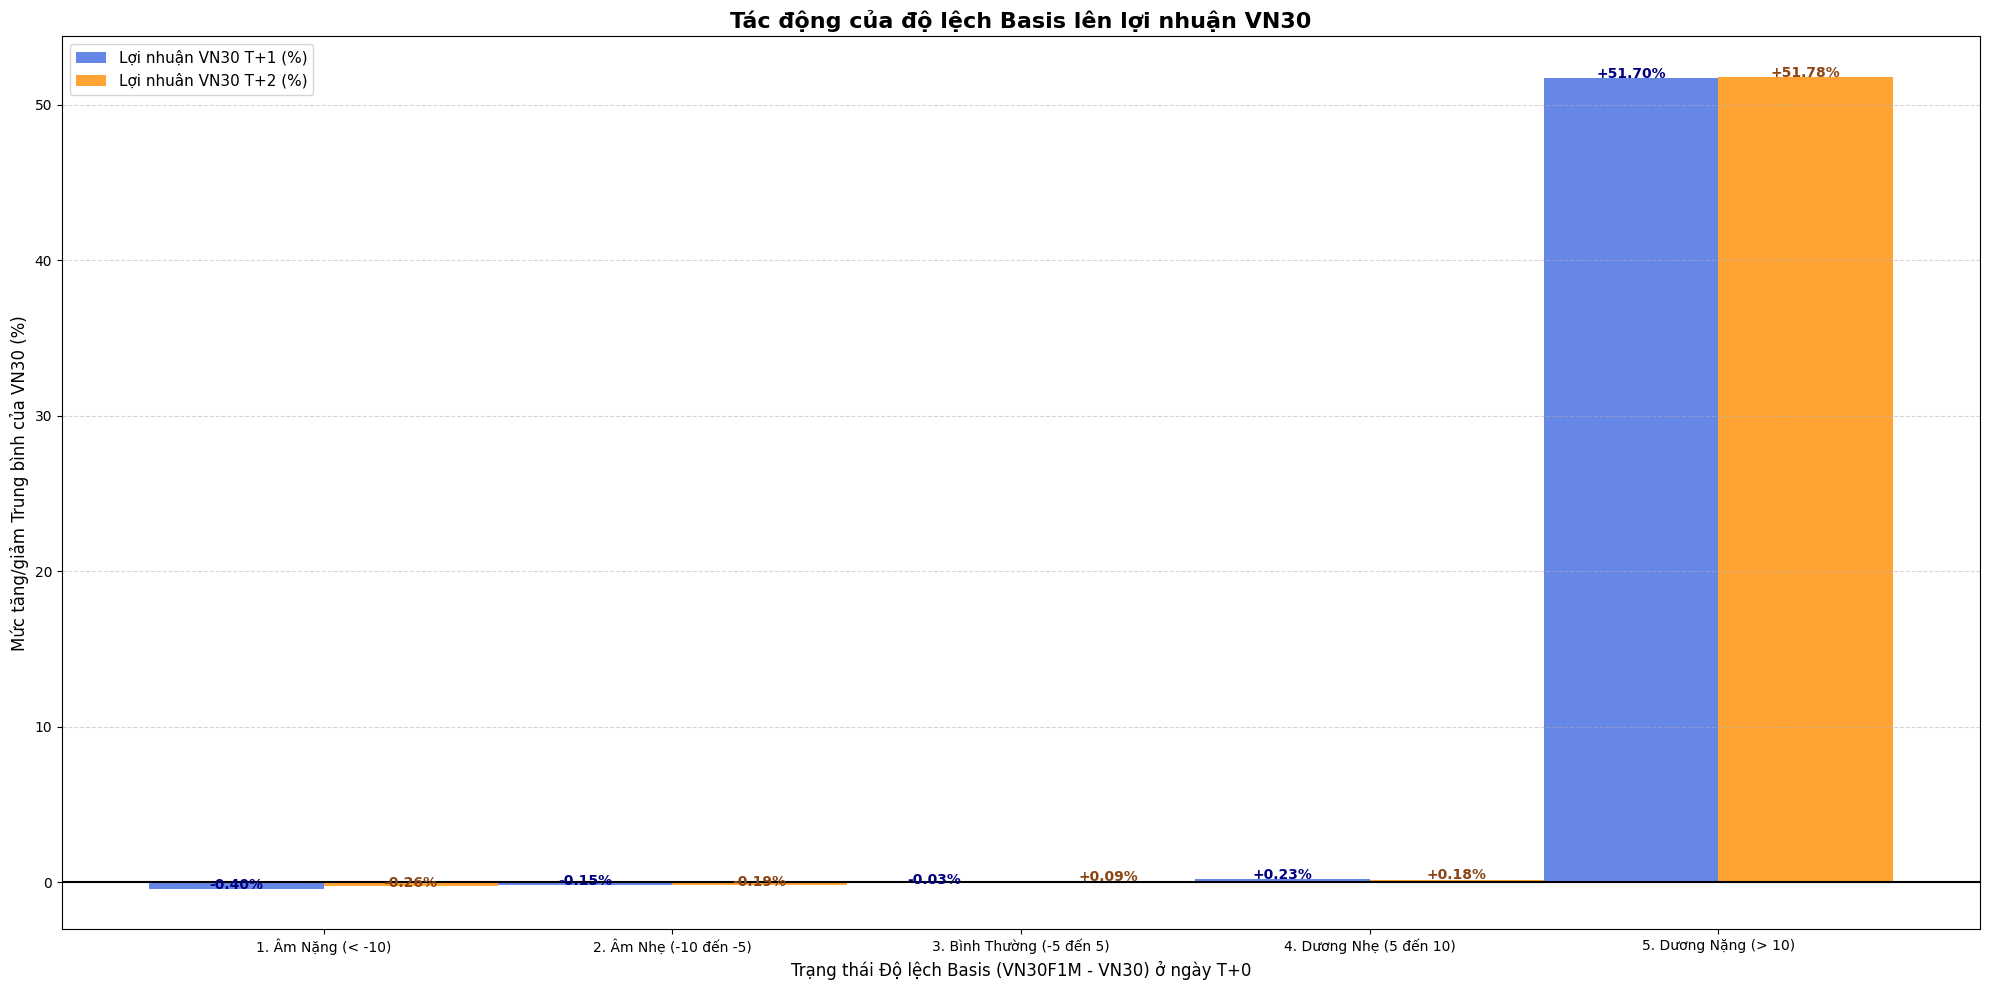

In [213]:
plt.figure(figsize=(20,10))
bar_width= 0.5
index= np.arange(len(check_basis))

plt.bar(index, check_basis["T_1"], bar_width, label="Lợi nhuận VN30 T+1 (%)", color="royalblue", alpha=0.8)
plt.bar(index+ bar_width,check_basis["T_2"], bar_width, label="Lợi nhuân VN30 T+2 (%)", color="darkorange", alpha=0.8)
plt.title("Tác động của độ lệch Basis lên lợi nhuận VN30", fontsize=16, fontweight= "bold");
plt.xticks(index+bar_width/2, [x for x in check_basis["Category_Basis"]]);
plt.axhline(0, color="black", linewidth=1.5);
plt.ylabel("Mức tăng/giảm Trung bình của VN30 (%)", fontsize=12)
plt.xlabel("Trạng thái Độ lệch Basis (VN30F1M - VN30) ở ngày T+0", fontsize=12);

for i, row in enumerate(check_basis.itertuples()):
    plt.text(i, row.T_1 + (0.015 if row.T_1 >= 0 else -0.04), 
             f"{row.T_1:+.2f}%", ha="center", fontsize=10, fontweight="bold", color="navy")
    plt.text(i + bar_width, row.T_2 + (0.015 if row.T_2 >= 0 else -0.04), 
             f"{row.T_2:+.2f}%", ha="center", fontsize=10, fontweight="bold", color="saddlebrown")

plt.legend(loc="upper left", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


**Nhận Xét**

### Biểu đồ Rủi ro và Lợi nhuận

In [214]:
# Tỷ suất sinh lời hàng ngày
risk_profit= df_stock.copy()
risk_profit["Daily_Return"]= risk_profit.groupby("Ticker")["Close"].pct_change()
risk_profit

,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,-0.007225
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,0.018923
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,0.001786
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.008200
...,...,...,...,...,...,...,...,...
25906,2026-03-13,VRE,25.60,26.00,25.25,25.25,3440100.0,-0.025097
25907,2026-03-16,VRE,25.25,25.90,25.10,25.90,4825600.0,0.025743
25908,2026-03-17,VRE,26.00,26.90,25.90,26.45,5159000.0,0.021236
25909,2026-03-18,VRE,26.50,26.95,26.10,26.10,3490200.0,-0.013233


In [215]:
count= risk_profit.groupby("Ticker")["Close"].count()
ticker_count= count[count>252].index
print(ticker_count)
risk_profit= risk_profit[risk_profit["Ticker"].isin(ticker_count)]
risk_profit

Index(['BID', 'BSR', 'CTG', 'FPT', 'GAS', 'GMD', 'HPG', 'MBB', 'MSR', 'OIL',
       'PLX', 'STB', 'TCB', 'VCB', 'VHM', 'VIC', 'VNM', 'VPB', 'VRE'],
      dtype='str', name='Ticker')


,Date,Ticker,Open,High,Low,Close,Volume,Daily_Return
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,-0.007225
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,0.018923
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,0.001786
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,-0.008200
...,...,...,...,...,...,...,...,...
25906,2026-03-13,VRE,25.60,26.00,25.25,25.25,3440100.0,-0.025097
25907,2026-03-16,VRE,25.25,25.90,25.10,25.90,4825600.0,0.025743
25908,2026-03-17,VRE,26.00,26.90,25.90,26.45,5159000.0,0.021236
25909,2026-03-18,VRE,26.50,26.95,26.10,26.10,3490200.0,-0.013233


In [216]:
# Lợi nhuận = Trung bình ngày * 252 ngày
# Rủi ro (Độ lệch chuẩn) = Độ lệch chuẩn ngày * căn bậc 2 của 252
metrics= risk_profit.groupby("Ticker")["Daily_Return"].agg(
    Profit=lambda x: x.mean() * 252 * 100,
    Risk=lambda x: x.std() * np.sqrt(252) * 100
).dropna().reset_index()
metrics


,Ticker,Profit,Risk
0,BID,12.769757,32.518626
1,BSR,43.209954,47.337696
2,CTG,19.866547,32.880572
3,FPT,25.137118,28.575480
4,GAS,13.648055,32.974834
5,GMD,28.512811,35.668668
6,HPG,13.660814,34.046677
7,MBB,28.197890,31.527925
8,MSR,30.234457,55.709898
9,OIL,18.786486,46.154132


In [217]:
median_profit= metrics["Profit"].median()
median_risk= metrics["Risk"].median()

def get_color(row):
    if row["Profit"] >= median_profit and row["Risk"] <= median_risk: 
        return "skyblue"
    elif row["Profit"] >= median_profit and row["Risk"] > median_risk: 
        return "orange"   
    elif row["Profit"] < median_profit and row["Risk"] <= median_risk: 
        return "gray"   
    else: 
        return "tomato"
metrics["Color"]= metrics.apply(get_color, axis=1)
metrics

,Ticker,Profit,Risk,Color
0,BID,12.769757,32.518626,gray
1,BSR,43.209954,47.337696,orange
2,CTG,19.866547,32.880572,skyblue
3,FPT,25.137118,28.575480,skyblue
4,GAS,13.648055,32.974834,gray
5,GMD,28.512811,35.668668,orange
6,HPG,13.660814,34.046677,tomato
7,MBB,28.197890,31.527925,skyblue
8,MSR,30.234457,55.709898,orange
9,OIL,18.786486,46.154132,orange


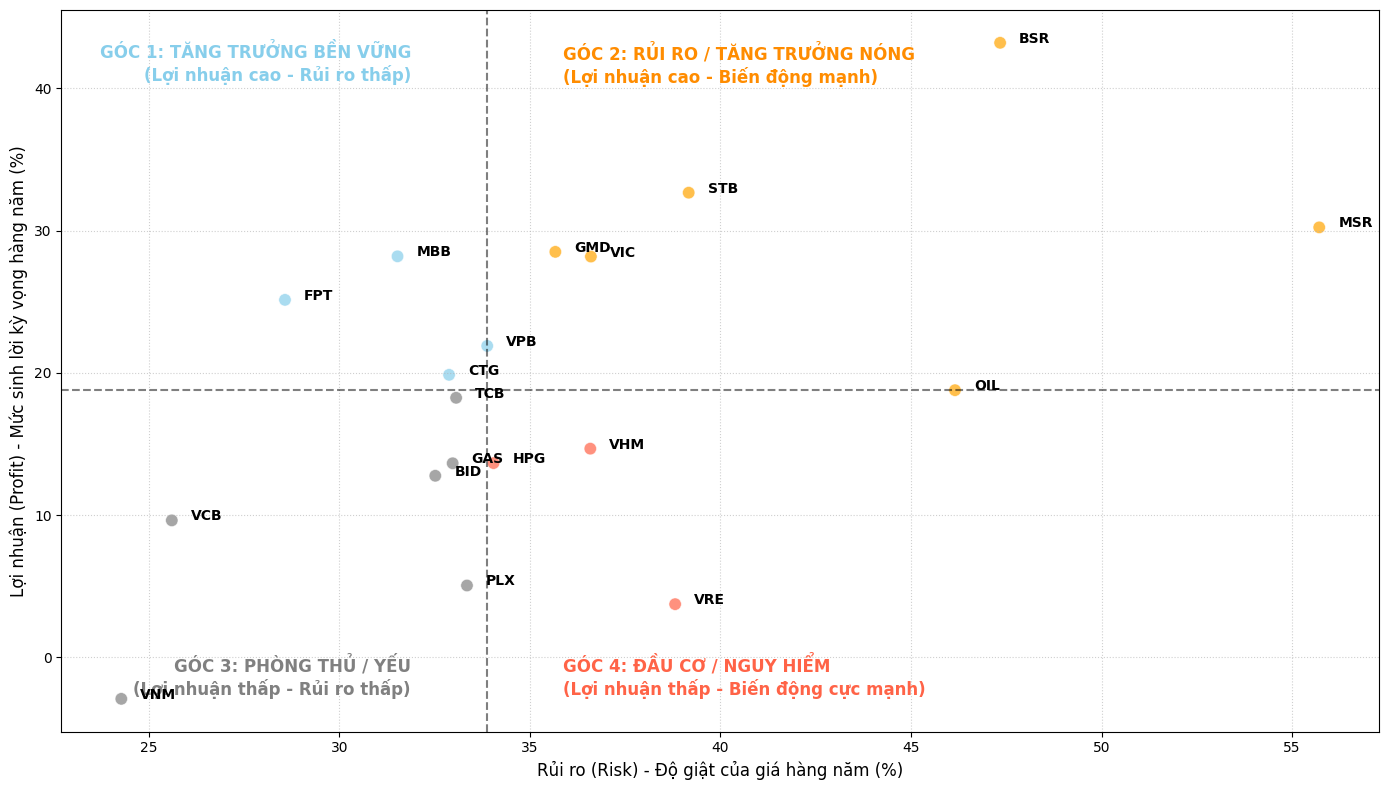

In [218]:
plt.figure(figsize=(14, 8))
plt.scatter(metrics["Risk"], metrics["Profit"], 
            c=metrics["Color"], s=80, alpha=0.7, edgecolors="white", linewidth=0.5)

plt.axvline(median_risk, color="black", linestyle="--", alpha=0.5)
plt.axhline(median_profit, color="black", linestyle="--", alpha=0.5)

plt.text(median_risk - 2, metrics["Profit"].max(), "GÓC 1: TĂNG TRƯỞNG BỀN VỮNG\n(Lợi nhuận cao - Rủi ro thấp)", 
         fontsize=12, color="skyblue", weight="bold", ha="right", va="top")
plt.text(median_risk + 2, metrics["Profit"].max(), "GÓC 2: RỦI RO / TĂNG TRƯỞNG NÓNG\n(Lợi nhuận cao - Biến động mạnh)", 
         fontsize=12, color="darkorange", weight="bold", ha="left", va="top")
plt.text(median_risk - 2, metrics["Profit"].min(), "GÓC 3: PHÒNG THỦ / YẾU\n(Lợi nhuận thấp - Rủi ro thấp)", 
         fontsize=12, color="gray", weight="bold", ha="right", va="bottom")
plt.text(median_risk + 2, metrics["Profit"].min(), "GÓC 4: ĐẦU CƠ / NGUY HIỂM\n(Lợi nhuận thấp - Biến động cực mạnh)", 
         fontsize=12, color="tomato", weight="bold", ha="left", va="bottom")


target_labels= risk_profit.Ticker.unique()
for idx, row in metrics.iterrows():
    ticker = row["Ticker"]
    if ticker in target_labels or row["Profit"] > 25 or row["Risk"] > 60:
        plt.text(row["Risk"] + 0.5, row["Profit"], ticker, 
                 fontsize=10, weight="bold", color="black")
        
plt.xlabel("Rủi ro (Risk) - Độ giật của giá hàng năm (%)", fontsize=12);
plt.ylabel("Lợi nhuận (Profit) - Mức sinh lời kỳ vọng hàng năm (%)", fontsize=12);
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# Data Processing and Feature Processing

- Vì thị trường Phái sinh (VN30F1M) năm 2017 mới xuất hiện nên ta sẽ lấy đây làm mốc bắt đầu
- Từ 2017->2026 (9 năm ) nên sẽ chia làm 3 mốc thời gian, mỗi mốc là 3 năm
* Giai đoạn 1 (2017-2019): Phái sinh mới xuất hiện, Basis nhiễu liên tục do thị trường chưa hiệu quả. Mô hình sẽ học được cách hình thành Phái sinh, Cơ sở, dòng tiền trước Covid
* Giai đoạn 2 (2020-2022): Tiền rẻ Covid bơm ra, F0 tràn ngập (2020-2021) đẩy thanh khoản x10 lần. Sau đó là cú sập lịch sử năm 2022 (Bắt bớ, Trái phiếu). Lấy mô hình đã học ở GDD1 dự đoán trên GĐ2. Sau đó gộp dữ liệu lại GDD1+GDD2
* Giai đoạn 3 (2023-2026): Thay đổi thành T+2.5, thanh khoản ổn định, thao túng thị trường tinh vi hơn

### Xử lý giá trị bị thiếu
- Có 1 vấn đề ở đây, như đã biết dữ liệu bị mất hoàn toàn không phải dạng NaN, cho nên phải lấy bộ lịch chuẩn (Không bao gồm các ngày nghỉ) của cả thị trường để dùng. Và những mã chỉ số thị trường (VNINDEX, VN30, VN30F1M) bị mất vào những ngày giao dịch bình thường (2020-05-12) cho nên không thể dùng ffill và bfill được -> Sẽ chuyển sang nội suy tuyến tính 

In [219]:
df_stock[df_stock.Date=="2024-05-17"].head()

,Date,Ticker,Open,High,Low,Close,Volume
837,2024-05-17,BID,40.58,40.62,40.21,40.34,1518300.0
2133,2024-05-17,BSR,11.73,11.85,11.73,11.79,6801900.0
3421,2024-05-17,CTG,22.87,22.91,22.57,22.70,5948500.0
4717,2024-05-17,FPT,99.10,99.53,97.85,98.44,2306400.0
6013,2024-05-17,GAS,65.27,65.27,64.68,64.84,965100.0


In [220]:
# Có thể thấy không có VNINDEX
df_market[df_market.Date=="2024-05-17"]

,Date,Ticker,Open,High,Low,Close,Volume
21564,2024-05-17,VN30F1M,1306.80,1308.20,1301.90,1307.90,176193.0
28041,2024-05-17,VN30,1309.27,1312.95,1304.14,1310.15,269818400.0


In [221]:
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 28498 entries, 0 to 28497
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    28498 non-null  datetime64[us]
 1   Ticker  28498 non-null  str           
 2   Open    28498 non-null  float64       
 3   High    28498 non-null  float64       
 4   Low     28498 non-null  float64       
 5   Close   28498 non-null  float64       
 6   Volume  28498 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 1.6 MB


In [222]:
df_all.Date.min()

Timestamp('2021-01-04 00:00:00')

In [223]:
calendar_full= pd.Series(sorted(df_all.Date.unique()))
filter_date= calendar_full[calendar_full>="2021-01-04"].reset_index(drop=True)
filter_date

0      2021-01-04
1      2021-01-05
2      2021-01-06
3      2021-01-07
4      2021-01-08
          ...    
1291   2026-03-13
1292   2026-03-16
1293   2026-03-17
1294   2026-03-18
1295   2026-03-19
Length: 1296, dtype: datetime64[us]

In [224]:
df_filter= df_all[df_all.Date.isin(filter_date)].copy()
df_filter

,Date,Ticker,Open,High,Low,Close,Volume
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0
...,...,...,...,...,...,...,...
28493,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0
28494,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0
28495,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0
28496,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0


In [225]:
market_tickers= ["VNINDEX", "VN30", "VN30F1M"]
cleaned_data= []
price_cols= ["Open", "High", "Low", "Close"]
for ticker in df_filter.Ticker.unique():
    ticker_df= df_filter[df_filter.Ticker == ticker].set_index("Date")
    start_date= ticker_df.index.min()
    end_date= ticker_df.index.max()

    ticker_calendar= filter_date[(filter_date >= start_date) & (filter_date <= end_date)]
    ticker_reindex= ticker_df.reindex(ticker_calendar)
    ticker_reindex["Ticker"]= ticker
    
    if ticker in market_tickers:
        ticker_reindex[price_cols]= ticker_reindex[price_cols].interpolate(method='linear').bfill().ffill()
        ticker_reindex["Volume"]= ticker_reindex["Volume"].interpolate(method='linear').bfill().ffill()
        
    else:
        ticker_reindex[price_cols]= ticker_reindex[price_cols].ffill().bfill()
        ticker_reindex["Volume"]= ticker_reindex["Volume"].fillna(0)
    cleaned_data.append(ticker_reindex)

df_final= pd.concat(cleaned_data).reset_index()


In [226]:
df_final.rename(columns={"index": "Date"}, inplace=True)
df_final

,Date,Ticker,Open,High,Low,Close,Volume
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0
...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0


In [227]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 28510 entries, 0 to 28509
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    28510 non-null  datetime64[us]
 1   Ticker  28510 non-null  str           
 2   Open    28510 non-null  float64       
 3   High    28510 non-null  float64       
 4   Low     28510 non-null  float64       
 5   Close   28510 non-null  float64       
 6   Volume  28510 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 1.6 MB


In [228]:
28510-28498

12

**Nhận Xét**
- Tại sao thiếu cả 2 file là 10 dữ liệu mà khi fill lại thành 12 dữ liệu
    * Bởi vì: Ở 2 file excel chứa market vào trường hợp đặc biệt 1 ngày thiếu cả 2 là VNINDEX và VN30 nên thuật toán cho rằng đó là ngày nghỉ-> ghi ra missing report
    * Sang file csv cào bằng api trong đó có mã chứng khoán và market, và đúng vào ngày đấy cũng thiếu, nhưng thuật toán đã ghi nhận các phiên giao dịch chứng khoán có hoạt động -> đây không phải ngày nghỉ
    * -> và khi nối 2 bảng lại thuật toán đã phát hiện ra có 2 mã VNINDEX và VN30 thiếu nên phải thêm vào


In [229]:
summary_all, details_all= missing_date(df_all, output_file="Missing_Dates_Report_ALL.csv")
if not summary_all.empty:
    display(summary_all)

Đã lưu ra file:Missing_Dates_Report_ALL.csv


,Ticker,Missing_Days_Count
0,BSR,8
2,VNINDEX,2
1,VN30F1M,1
3,VN30,1


## Tạo bộ lọc dòng tiền


### Đột biến Khối lượng (Vol_Spike): Phát hiện dòng tiền lớn gấp n lần trung bình

$$Vol\_Spike = \frac{Volume_{today}}{SMA(Volume, 20)}$$

- Vol_Spike = 1: Dòng tiền bình thường.

- Vol_Spike > 1.5: Dòng tiền lớn bắt đầu chú ý (Đáng đưa vào radar).

- Vol_Spike > 2.0 hoặc 3.0: "Tay to" (Big Boys) chính thức gom hàng hoặc xả hàng (Tùy thuộc vào giá tăng hay giảm).

In [230]:
df_features= df_final.copy()

In [231]:
df_features["Vol_MA20"]= df_features.groupby("Ticker")["Volume"].transform(lambda x: x.rolling(window=20, min_periods=1).mean())
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06
...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08


In [232]:
df_features["Vol_Spike"]= df_features["Volume"] / df_features["Vol_MA20"].replace(0, np.nan)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.000000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.039017
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.408934
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.706551
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.881871
...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.888607
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.782586
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.661104
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.627662


In [233]:
df_features["Vol_Spike"]= df_features["Vol_Spike"].fillna(0)
df_features["Vol_Spike"]= df_features["Vol_Spike"].round(2)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88
...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63


### OBV (On-Balance Volume): Tìm kiếm sự phân kỳ (giá đi ngang nhưng tiền vẫn âm thầm bơm vào)

$$OBV_t = 
\begin{cases} 
OBV_{t-1} + Volume_t & \text{nếu } Close_t > Close_{t-1} \\
OBV_{t-1} - Volume_t & \text{nếu } Close_t < Close_{t-1} \\
OBV_{t-1} & \text{nếu } Close_t = Close_{t-1} 
\end{cases}$$

In [234]:
df_features["Close_Diff"]= df_features.groupby("Ticker")["Close"].diff()
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,Close_Diff
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-0.20
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,0.52
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,0.05
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,-0.23
...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,-30.14
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,-6.20
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,-0.61
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,20.66


In [235]:
conditional= [
    df_features["Close_Diff"]>0,
    df_features["Close_Diff"]<0
]
choice= [
    df_features["Volume"],
    -df_features["Volume"]
]

df_features["Daily_OBV"]= np.select(conditional,choice, default=0)
df_features


,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,Close_Diff,Daily_OBV
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,NaN,0.0
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-0.20,-2155700.0
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,0.52,3674500.0
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,0.05,1678500.0
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,-0.23,-2034900.0
...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,-30.14,-380808184.0
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,-6.20,-329393500.0
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,-0.61,-279631333.0
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,20.66,262441729.0


In [236]:
df_features["OBV"]= df_features.groupby("Ticker")['Daily_OBV'].cumsum()
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,Close_Diff,Daily_OBV,OBV
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,NaN,0.0,0.000000e+00
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-0.20,-2155700.0,-2.155700e+06
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,0.52,3674500.0,1.518800e+06
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,0.05,1678500.0,3.197300e+06
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,-0.23,-2034900.0,1.162400e+06
...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,-30.14,-380808184.0,3.005620e+10
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,-6.20,-329393500.0,2.972681e+10
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,-0.61,-279631333.0,2.944718e+10
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,20.66,262441729.0,2.970962e+10


In [237]:
df_features["OBV_MA20"]= df_features.groupby("Ticker")["OBV"].transform(lambda x: x.rolling(window=20, min_periods=1).mean())
df_features["OBV_STD20"]= df_features.groupby("Ticker")["OBV"].transform(lambda x: x.rolling(window=20, min_periods=1).std())
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,Close_Diff,Daily_OBV,OBV,OBV_MA20,OBV_STD20
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,NaN,0.0,0.000000e+00,0.000000e+00,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-0.20,-2155700.0,-2.155700e+06,-1.077850e+06,1.524310e+06
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,0.52,3674500.0,1.518800e+06,-2.123000e+05,1.846427e+06
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,0.05,1678500.0,3.197300e+06,6.401000e+05,2.275786e+06
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,-0.23,-2034900.0,1.162400e+06,7.445600e+05,1.984682e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,-30.14,-380808184.0,3.005620e+10,3.083857e+10,8.036150e+08
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,-6.20,-329393500.0,2.972681e+10,3.082323e+10,8.224885e+08
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,-0.61,-279631333.0,2.944718e+10,3.078201e+10,8.708300e+08
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,20.66,262441729.0,2.970962e+10,3.073594e+10,9.030168e+08


In [238]:
df_features["OBV_Zscore"]= (df_features["OBV"] - df_features["OBV_MA20"]) / df_features["OBV_STD20"].replace(0, np.nan)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,Close_Diff,Daily_OBV,OBV,OBV_MA20,OBV_STD20,OBV_Zscore
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,NaN,0.0,0.000000e+00,0.000000e+00,NaN,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-0.20,-2155700.0,-2.155700e+06,-1.077850e+06,1.524310e+06,-0.707107
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,0.52,3674500.0,1.518800e+06,-2.123000e+05,1.846427e+06,0.937541
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,0.05,1678500.0,3.197300e+06,6.401000e+05,2.275786e+06,1.123656
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,-0.23,-2034900.0,1.162400e+06,7.445600e+05,1.984682e+06,0.210532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,-30.14,-380808184.0,3.005620e+10,3.083857e+10,8.036150e+08,-0.973558
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,-6.20,-329393500.0,2.972681e+10,3.082323e+10,8.224885e+08,-1.333060
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,-0.61,-279631333.0,2.944718e+10,3.078201e+10,8.708300e+08,-1.532831
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,20.66,262441729.0,2.970962e+10,3.073594e+10,9.030168e+08,-1.136545


In [239]:
df_features["OBV_Zscore"]= df_features["OBV_Zscore"].fillna(0).round(2)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,Close_Diff,Daily_OBV,OBV,OBV_MA20,OBV_STD20,OBV_Zscore
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,NaN,0.0,0.000000e+00,0.000000e+00,NaN,0.00
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-0.20,-2155700.0,-2.155700e+06,-1.077850e+06,1.524310e+06,-0.71
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,0.52,3674500.0,1.518800e+06,-2.123000e+05,1.846427e+06,0.94
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,0.05,1678500.0,3.197300e+06,6.401000e+05,2.275786e+06,1.12
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,-0.23,-2034900.0,1.162400e+06,7.445600e+05,1.984682e+06,0.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,-30.14,-380808184.0,3.005620e+10,3.083857e+10,8.036150e+08,-0.97
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,-6.20,-329393500.0,2.972681e+10,3.082323e+10,8.224885e+08,-1.33
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,-0.61,-279631333.0,2.944718e+10,3.078201e+10,8.708300e+08,-1.53
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,20.66,262441729.0,2.970962e+10,3.073594e+10,9.030168e+08,-1.14


In [240]:
df_features.drop(columns=["Close_Diff", "Daily_OBV", "OBV_MA20", "OBV_STD20"], inplace=True)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,OBV_Zscore
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,0.00
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,-0.71
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,0.94
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,1.12
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,0.21
...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,-0.97
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,-1.33
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,-1.53
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,-1.14


### CMF (Chaikin Money Flow): Đo lường áp lực Mua/Bán chủ động trong phiên
Bước 1: Tính Hệ số Dòng tiền (Money Flow Multiplier) Đo lường xem giá đóng cửa nằm ở đâu so với biên độ của cây nến.$$MF\_Multiplier = \frac{(Close - Low) - (High - Close)}{High - Low}$$
- Nếu đóng cửa ở mức cao nhất phiên ($Close = High$): Hệ số là $+1$ (Lực mua tuyệt đối)
- .Nếu đóng cửa ở mức thấp nhất phiên ($Close = Low$): Hệ số là $-1$ (Lực bán tuyệt đối).Nếu đóng cửa ở giữa phiên: Hệ số là $0$ (Giằng co cân bằng).

Bước 2: Tính Khối lượng Dòng tiền (Money Flow Volume)$$MF\_Volume = MF\_Multiplier \times Volume$$
Bước 3: Tính CMF (Thường dùng chu kỳ 20 phiên)$$CMF = \frac{\sum_{i=1}^{20} MF\_Volume_i}{\sum_{i=1}^{20} Volume_i}$$

- CMF > 0.20: Dòng tiền mua chủ động rất mạnh và liên tục. Tay to đang gom hàng quyết liệt, sẵn sàng đánh vượt đỉnh (Breakout).

- CMF < -0.20: Áp lực xả hàng tàng hình. Dù giá có thể chưa giảm sâu, nhưng cấu trúc nến liên tục bị chốt ngược. AI sẽ nhận diện đây là vùng rủi ro và kích hoạt lệnh Bán/Short.

- CMF quanh mức 0: Trạng thái lình xình, không có bên nào kiểm soát thế trận.

In [241]:
high_low_diff= df_features["High"] - df_features["Low"]
high_low_diff

0         0.40
1         0.25
2         1.75
3         0.81
4         0.64
         ...  
28505    28.44
28506    34.93
28507    22.10
28508    33.31
28509    40.46
Length: 28510, dtype: float64

In [242]:
df_features["MF_Multiplier"]= np.where(
    high_low_diff == 0, 
    0, 
    ((df_features["Close"] - df_features["Low"]) - (df_features["High"] - df_features["Close"])) / high_low_diff
)
df_features


,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,OBV_Zscore,MF_Multiplier
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,0.00,0.400000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,-0.71,0.120000
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,0.94,-0.188571
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,1.12,-0.432099
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,0.21,-0.468750
...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,-0.97,-0.395218
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,-1.33,-0.192098
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,-1.53,0.021719
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,-1.14,-0.698589


In [243]:
df_features["MF_Volume"]= df_features["MF_Multiplier"] * df_features["Volume"]
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,OBV_Zscore,MF_Multiplier,MF_Volume
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,0.00,0.400000,7.975200e+05
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,-0.71,0.120000,2.586840e+05
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,0.94,-0.188571,-6.929057e+05
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,1.12,-0.432099,-7.252778e+05
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,0.21,-0.468750,-9.538594e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,-0.97,-0.395218,-1.505022e+08
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,-1.33,-0.192098,-6.327599e+07
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,-1.53,0.021719,6.073441e+06
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,-1.14,-0.698589,-1.833389e+08


In [244]:
sum_mfv= df_features.groupby("Ticker")["MF_Volume"].transform(lambda x: x.rolling(window=20, min_periods=1).sum())
sum_vol= df_features.groupby("Ticker")["Volume"].transform(lambda x: x.rolling(window=20, min_periods=1).sum())

In [245]:
df_features["CMF"]= np.where(
    sum_vol == 0,
    0,
    sum_mfv / sum_vol
)
df_features["CMF"]= df_features["CMF"].round(2)

In [246]:
df_features.drop(columns=['MF_Multiplier', 'MF_Volume'], inplace=True)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,OBV_Zscore,CMF
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,0.00,0.40
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,-0.71,0.25
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,0.94,0.05
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,1.12,-0.04
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,0.21,-0.11
...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,-0.97,-0.23
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,-1.33,-0.19
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,-1.53,-0.17
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,-1.14,-0.19


### VSA Signals: Nhận diện nến Gom hàng, Xả hàng, Cao trào bán (Selling Climax), Bẫy bứt phá (Bull-trap)

<table style="width: 100%;">
  <tr align="center">
    <td><img src="images/fakebreak.jpg" style="width: 100%;"></td>
    <td><img src="images/sell3.jpg" style="width: 100%;"></td>
    <td><img src="images/trap3.jpg" style="width: 100%;"></td>
  </tr>
  <tr align="center">
    <td><i>Fakebreak</i></td>
    <td><i>Sell Signal</i></td>
    <td><i>Bull Trap</i></td>
  </tr>
</table>

$$Spread = High - Low \quad \text{(Biên độ toàn nến)}$$

$$Body = |Close - Open| \quad \text{(Độ dài Thân nến)}$$

$$Upper\_Wick = High - \max(Open, Close) \quad \text{(Độ dài Râu trên)}$$

$$Lower\_Wick = \min(Open, Close) - Low \quad \text{(Độ dài Râu dưới)}$$

$$Close\_Pos = \frac{Close - Low}{Spread} \quad \text{(Vị trí đóng cửa, thang điểm 0 - 1)}$$

1. Selling Climax (Cao trào bán / Nến rút chân tạo đáy)
    - Tín hiệu này xuất hiện khi đám đông hoảng loạn bán tháo nhưng "Tay to" đã giăng lưới hứng hết lực bán và kéo giá rút chân lên.$$Selling\_Climax = 
\begin{cases} 
1 & \text{nếu } Vol\_Spike > 1.5 \text{ } \mathbf{AND} \text{ } Lower\_Wick > Body \text{ } \mathbf{AND} \text{ } Close\_Pos \ge 0.5 \\
0 & \text{trường hợp khác}
\end{cases}$$

2. Bull Trap / Upthrust (Bẫy bứt phá / Nến cụt đầu)
    - Tín hiệu này cho thấy đám đông FOMO mua đuổi giá cao, nhưng bị "Tay to" mang hàng ra xả ép giá đóng cửa cắm đầu xuống.$$Bull\_Trap = 
\begin{cases} 
1 & \text{nếu } Vol\_Spike > 1.5 \text{ } \mathbf{AND} \text{ } Upper\_Wick > Body \text{ } \mathbf{AND} \text{ } Close\_Pos \le 0.4 \\
0 & \text{trường hợp khác}
\end{cases}$$

3. Distribution (Xả hàng chủ động / Phân phối)
    - Khác với Bull Trap là xả lén lút, Distribution là hiện tượng dứt khoát bán thẳng tay lệnh lớn, tạo ra cây nến đỏ đặc, thân dài áp đảo.$$Distribution = 
\begin{cases} 
1 & \text{nếu } Vol\_Spike > 1.5 \text{ } \mathbf{AND} \text{ } Close < Open \text{ } \mathbf{AND} \text{ } Body > \max(Upper\_Wick, Lower\_Wick) \\
0 & \text{trường hợp khác}
\end{cases}$$

4. No Supply (Cạn cung / Test cung)
    - Nhịp kiểm tra thanh khoản của "Tay to". Nếu đạp giá xuống nhẹ mà không còn ai mang hàng ra bán (Volume mất hút), nhịp kéo thốc đẩy giá (Markup) sẽ sớm diễn ra.$$No\_Supply = 
\begin{cases} 
1 & \text{nếu } Close < Close_{t-1} \text{ } \mathbf{AND} \text{ } Vol\_Spike \le 0.7 \text{ } \mathbf{AND} \text{ } Spread < SMA(Spread, 20) \\
0 & \text{trường hợp khác}
\end{cases}$$

In [247]:
df_features["Spread"]= df_features["High"] - df_features["Low"]
df_features["Body"] = abs(df_features["Close"] - df_features["Open"])
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,OBV_Zscore,CMF,Spread,Body
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,0.00,0.40,0.40,0.28
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,-0.71,0.25,0.25,0.00
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,0.94,0.05,1.75,0.29
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,1.12,-0.04,0.81,0.05
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,0.21,-0.11,0.64,0.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,-0.97,-0.23,28.44,3.12
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,-1.33,-0.19,34.93,6.09
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,-1.53,-0.17,22.10,1.81
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,-1.14,-0.19,33.31,4.50


In [248]:
df_features["Upper_Wick"]= df_features["High"] - df_features[["Open", "Close"]].max(axis=1)
df_features["Lower_Wick"]= df_features[["Open", "Close"]].min(axis=1) - df_features["Low"]
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,OBV_Zscore,CMF,Spread,Body,Upper_Wick,Lower_Wick
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,0.00,0.40,0.40,0.28,0.12,0.00
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,-0.71,0.25,0.25,0.00,0.11,0.14
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,0.94,0.05,1.75,0.29,1.04,0.42
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,1.12,-0.04,0.81,0.05,0.58,0.18
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,0.21,-0.11,0.64,0.47,0.00,0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,-0.97,-0.23,28.44,3.12,16.72,8.60
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,-1.33,-0.19,34.93,6.09,20.82,8.02
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,-1.53,-0.17,22.10,1.81,9.00,11.29
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,-1.14,-0.19,33.31,4.50,28.29,0.52


In [249]:
df_features["Close_Pos"]= np.where(
    df_features["Spread"] == 0, 
    0.5, 
    (df_features["Close"] - df_features["Low"]) / df_features["Spread"]
)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,OBV_Zscore,CMF,Spread,Body,Upper_Wick,Lower_Wick,Close_Pos
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,0.00,0.40,0.40,0.28,0.12,0.00,0.700000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,-0.71,0.25,0.25,0.00,0.11,0.14,0.560000
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,0.94,0.05,1.75,0.29,1.04,0.42,0.405714
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,1.12,-0.04,0.81,0.05,0.58,0.18,0.283951
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,0.21,-0.11,0.64,0.47,0.00,0.17,0.265625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,-0.97,-0.23,28.44,3.12,16.72,8.60,0.302391
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,-1.33,-0.19,34.93,6.09,20.82,8.02,0.403951
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,-1.53,-0.17,22.10,1.81,9.00,11.29,0.510860
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,-1.14,-0.19,33.31,4.50,28.29,0.52,0.150705


In [250]:
df_features["Prev_Close"]= df_features.groupby("Ticker")["Close"].shift(1)
df_features["Spread_MA20"]= df_features.groupby("Ticker")["Spread"].transform(lambda x: x.rolling(20, min_periods=1).mean())
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,OBV_Zscore,CMF,Spread,Body,Upper_Wick,Lower_Wick,Close_Pos,Prev_Close,Spread_MA20
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,0.00,0.40,0.40,0.28,0.12,0.00,0.700000,NaN,0.4000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,-0.71,0.25,0.25,0.00,0.11,0.14,0.560000,27.68,0.3250
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,0.94,0.05,1.75,0.29,1.04,0.42,0.405714,27.48,0.8000
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,1.12,-0.04,0.81,0.05,0.58,0.18,0.283951,28.00,0.8025
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,0.21,-0.11,0.64,0.47,0.00,0.17,0.265625,28.05,0.7700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,-0.97,-0.23,28.44,3.12,16.72,8.60,0.302391,1889.94,39.9875
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,-1.33,-0.19,34.93,6.09,20.82,8.02,0.403951,1859.80,40.4545
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,-1.53,-0.17,22.10,1.81,9.00,11.29,0.510860,1853.60,40.6760
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,-1.14,-0.19,33.31,4.50,28.29,0.52,0.150705,1852.99,40.6315


In [251]:
df_features["VSA_Selling_Climax"]= np.where(
    (df_features["Vol_Spike"] > 1.5) & 
    (df_features["Lower_Wick"] > df_features["Body"]) & 
    (df_features["Close_Pos"] >= 0.5), 
    1, 0
)

df_features["VSA_Bull_Trap"]= np.where(
    (df_features["Vol_Spike"] > 1.5) & 
    (df_features["Upper_Wick"] > df_features["Body"]) & 
    (df_features["Close_Pos"] <= 0.4), 
    1, 0
)

df_features["VSA_Distribution"]= np.where(
    (df_features["Vol_Spike"] > 1.5) & 
    (df_features["Close"] < df_features["Open"]) & 
    (df_features["Body"] > df_features["Upper_Wick"]) & 
    (df_features["Body"] > df_features["Lower_Wick"]), 
    1, 0
)

df_features["VSA_No_Supply"]= np.where(
    (df_features["Close"] < df_features["Prev_Close"]) & 
    (df_features["Vol_Spike"] <= 0.7) & 
    (df_features["Spread"] < df_features["Spread_MA20"]), 
    1, 0
)

In [252]:
df_features.drop(columns=["Prev_Close", "Spread_MA20", "Spread", "Body", "Upper_Wick", "Lower_Wick", "Close_Pos"], inplace=True)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,OBV_Zscore,CMF,VSA_Selling_Climax,VSA_Bull_Trap,VSA_Distribution,VSA_No_Supply
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,0.00,0.40,0,0,0,0
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,-0.71,0.25,0,0,0,0
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,0.94,0.05,0,0,0,0
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,1.12,-0.04,0,0,0,0
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,0.21,-0.11,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,-0.97,-0.23,0,0,0,0
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,-1.33,-0.19,0,0,0,0
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,-1.53,-0.17,0,0,0,1
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,-1.14,-0.19,0,0,0,0


## Tạo bộ lọc tâm lý và kỹ thuật

### Xu hướng (MA20, MA50, MACD)

In [253]:
ma20= df_features.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=20, min_periods=1).mean())
ma50= df_features.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=50, min_periods=1).mean())
ma20, ma50

(0          27.6800
 1          27.5800
 2          27.7200
 3          27.8025
 4          27.8060
            ...    
 28505    1962.2560
 28506    1957.7560
 28507    1953.0180
 28508    1949.1215
 28509    1942.5185
 Name: Close, Length: 28510, dtype: float64,
 0          27.6800
 1          27.5800
 2          27.7200
 3          27.8025
 4          27.8060
            ...    
 28505    2008.1064
 28506    2004.7158
 28507    2002.2514
 28508    2000.4050
 28509    1997.9686
 Name: Close, Length: 28510, dtype: float64)

In [254]:
# Nếu > 0: Nằm trên MA (Uptrend). Nếu < 0: Nằm dưới MA (Downtrend)
df_features["Dist_MA20"]= (df_features["Close"] / ma20)- 1
df_features["Dist_MA50"]= (df_features["Close"] / ma50)- 1

df_features["Dist_MA20"]= df_features["Dist_MA20"].round(4)
df_features["Dist_MA50"]= df_features["Dist_MA50"].round(4)
df_features


,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,OBV_Zscore,CMF,VSA_Selling_Climax,VSA_Bull_Trap,VSA_Distribution,VSA_No_Supply,Dist_MA20,Dist_MA50
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,0.00,0.40,0,0,0,0,0.0000,0.0000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,-0.71,0.25,0,0,0,0,-0.0036,-0.0036
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,0.94,0.05,0,0,0,0,0.0101,0.0101
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,1.12,-0.04,0,0,0,0,0.0089,0.0089
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,0.21,-0.11,0,0,0,0,0.0005,0.0005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,-0.97,-0.23,0,0,0,0,-0.0522,-0.0739
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,-1.33,-0.19,0,0,0,0,-0.0532,-0.0754
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,-1.53,-0.17,0,0,0,1,-0.0512,-0.0745
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,-1.14,-0.19,0,0,0,0,-0.0387,-0.0634


In [255]:
ema12= df_features.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=12, adjust=False).mean())
ema26= df_features.groupby("Ticker")["Close"].transform(lambda x: x.ewm(span=26, adjust=False).mean())
macd_line= ema12 - ema26
macd_signal= macd_line.groupby(df_features["Ticker"]).transform(lambda x: x.ewm(span=9, adjust=False).mean())
df_features["MACD_Hist"]= macd_line - macd_signal
df_features["MACD_Hist"]= df_features["MACD_Hist"].round(4)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,OBV_Zscore,CMF,VSA_Selling_Climax,VSA_Bull_Trap,VSA_Distribution,VSA_No_Supply,Dist_MA20,Dist_MA50,MACD_Hist
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,0.00,0.40,0,0,0,0,0.0000,0.0000,0.0000
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,-0.71,0.25,0,0,0,0,-0.0036,-0.0036,-0.0128
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,0.94,0.05,0,0,0,0,0.0101,0.0101,0.0131
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,1.12,-0.04,0,0,0,0,0.0089,0.0089,0.0318
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,0.21,-0.11,0,0,0,0,0.0005,0.0005,0.0272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,-0.97,-0.23,0,0,0,0,-0.0522,-0.0739,-17.2288
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,-1.33,-0.19,0,0,0,0,-0.0532,-0.0754,-15.3330
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,-1.53,-0.17,0,0,0,1,-0.0512,-0.0745,-13.1413
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,-1.14,-0.19,0,0,0,0,-0.0387,-0.0634,-9.4916


### Độ nén/Biến động (Bollinger Bands)

In [256]:
bb_std= df_features.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=20, min_periods=1).std())
bb_std

0              NaN
1         0.141421
2         0.262298
3         0.270355
4         0.234265
           ...    
28505    80.946117
28506    84.463098
28507    87.651555
28508    89.432910
28509    90.279909
Name: Close, Length: 28510, dtype: float64

In [257]:
# Tính Dải trên (Upper) và Dải dưới (Lower)
bb_upper= ma20 + (2 * bb_std)
bb_lower= ma20 - (2 * bb_std)


In [258]:
# Bandwidth (Độ nén)
df_features["BB_Width"]= (bb_upper - bb_lower) / ma20.replace(0, np.nan)
# %B (Vị trí của giá)
df_features["BB_Pos"]= (df_features["Close"] - bb_lower) / (bb_upper - bb_lower).replace(0, np.nan)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,...,CMF,VSA_Selling_Climax,VSA_Bull_Trap,VSA_Distribution,VSA_No_Supply,Dist_MA20,Dist_MA50,MACD_Hist,BB_Width,BB_Pos
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,...,0.40,0,0,0,0,0.0000,0.0000,0.0000,NaN,NaN
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,...,0.25,0,0,0,0,-0.0036,-0.0036,-0.0128,0.020511,0.323223
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,...,0.05,0,0,0,0,0.0101,0.0101,0.0131,0.037850,0.766872
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,...,-0.04,0,0,0,0,0.0089,0.0089,0.0318,0.038896,0.728866
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,...,-0.11,0,0,0,0,0.0005,0.0005,0.0272,0.033700,0.514940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,...,-0.23,0,0,0,0,-0.0522,-0.0739,-17.2288,0.165006,0.183567
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,...,-0.19,0,0,0,0,-0.0532,-0.0754,-15.3330,0.172571,0.191712
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,...,-0.17,0,0,0,1,-0.0512,-0.0745,-13.1413,0.179520,0.214700
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,...,-0.19,0,0,0,0,-0.0387,-0.0634,-9.4916,0.183535,0.289028


In [259]:
df_features["BB_Width"]= df_features["BB_Width"].fillna(0).round(4)
df_features["BB_Pos"]= df_features["BB_Pos"].fillna(0.5).round(4)

### Chỉ số hoảng loạn/hưng phấn (RSI)
- RSI < 30 (Hoảng loạn tột độ): Đám đông đang giẫm đạp lên nhau bán tháo. Giá đã giảm quá nhanh so với giá trị thực
- RSI > 70 (Hưng phấn tột độ): Đám đông đang FOMO mua đuổi bất chấp giá cao. Lực mua đã cạn kiệt, bong bóng chực chờ vỡ
- RSI xoay quanh 50: Trạng thái tâm lý cân bằng, giằng co

In [260]:
delta= df_features.groupby("Ticker")["Close"].diff()
delta

0          NaN
1        -0.20
2         0.52
3         0.05
4        -0.23
         ...  
28505   -30.14
28506    -6.20
28507    -0.61
28508    20.66
28509    -4.81
Name: Close, Length: 28510, dtype: float64

In [261]:
gain= delta.clip(lower=0)
loss= -1 * delta.clip(upper=0)
gain, loss

(0          NaN
 1         0.00
 2         0.52
 3         0.05
 4         0.00
          ...  
 28505     0.00
 28506     0.00
 28507     0.00
 28508    20.66
 28509     0.00
 Name: Close, Length: 28510, dtype: float64,
 0          NaN
 1         0.20
 2        -0.00
 3        -0.00
 4         0.23
          ...  
 28505    30.14
 28506     6.20
 28507     0.61
 28508    -0.00
 28509     4.81
 Name: Close, Length: 28510, dtype: float64)

In [262]:
avg_gain= gain.groupby(df_features["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, min_periods=1, adjust=False).mean())
avg_loss= loss.groupby(df_features["Ticker"]).transform(lambda x: x.ewm(alpha=1/14, min_periods=1, adjust=False).mean())
avg_gain, avg_loss

(0              NaN
 1         0.000000
 2         0.037143
 3         0.038061
 4         0.035343
            ...    
 28505    16.054860
 28506    14.908085
 28507    13.843222
 28508    14.330134
 28509    13.306553
 Name: Close, Length: 28510, dtype: float64,
 0              NaN
 1         0.200000
 2         0.185714
 3         0.172449
 4         0.176560
            ...    
 28505    23.419721
 28506    22.189741
 28507    20.648331
 28508    19.173450
 28509    18.147489
 Name: Close, Length: 28510, dtype: float64)

In [263]:
rs= avg_gain / avg_loss
df_features["RSI_14"]= 100 - (100 / (1 + rs))
rs

0             NaN
1        0.000000
2        0.200000
3        0.220710
4        0.200173
           ...   
28505    0.685527
28506    0.671846
28507    0.670428
28508    0.747395
28509    0.733245
Name: Close, Length: 28510, dtype: float64

In [264]:
df_features["RSI_14"]= df_features["RSI_14"].fillna(50.0)
df_features["RSI_14"]= df_features["RSI_14"].round(2)
df_features

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,...,VSA_Selling_Climax,VSA_Bull_Trap,VSA_Distribution,VSA_No_Supply,Dist_MA20,Dist_MA50,MACD_Hist,BB_Width,BB_Pos,RSI_14
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,...,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.5000,50.00
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,...,0,0,0,0,-0.0036,-0.0036,-0.0128,0.0205,0.3232,0.00
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,...,0,0,0,0,0.0101,0.0101,0.0131,0.0378,0.7669,16.67
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,...,0,0,0,0,0.0089,0.0089,0.0318,0.0389,0.7289,18.08
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,...,0,0,0,0,0.0005,0.0005,0.0272,0.0337,0.5149,16.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,...,0,0,0,0,-0.0522,-0.0739,-17.2288,0.1650,0.1836,40.67
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,...,0,0,0,0,-0.0532,-0.0754,-15.3330,0.1726,0.1917,40.19
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,...,0,0,0,1,-0.0512,-0.0745,-13.1413,0.1795,0.2147,40.14
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,...,0,0,0,0,-0.0387,-0.0634,-9.4916,0.1835,0.2890,42.77


## Basis

In [265]:
df_vn30= df_features[df_features["Ticker"] == "VN30"][["Date", "Close"]].rename(columns={"Close": "VN30_Close"})
df_ps= df_features[df_features["Ticker"] == "VN30F1M"][["Date", "Close"]].rename(columns={"Close": "PS_Close"})
df_vn30.shape, df_ps.shape

((1295, 2), (1296, 2))

In [266]:
df_vn30, df_ps

(            Date  VN30_Close
 27215 2021-01-04     1091.87
 27216 2021-01-05     1104.30
 27217 2021-01-06     1113.72
 27218 2021-01-07     1130.59
 27219 2021-01-08     1147.86
 ...          ...         ...
 28505 2026-03-12     1859.80
 28506 2026-03-13     1853.60
 28507 2026-03-16     1852.99
 28508 2026-03-17     1873.65
 28509 2026-03-18     1868.84
 
 [1295 rows x 2 columns],
             Date  PS_Close
 20736 2021-01-04    1109.4
 20737 2021-01-05    1111.0
 20738 2021-01-06    1125.0
 20739 2021-01-07    1148.9
 20740 2021-01-08    1176.6
 ...          ...       ...
 22027 2026-03-13    1840.0
 22028 2026-03-16    1851.3
 22029 2026-03-17    1877.0
 22030 2026-03-18    1881.9
 22031 2026-03-19    1858.2
 
 [1296 rows x 2 columns])

In [267]:
# Tại vì API lấy về phải sang ngày hôm sau mới cập nhật
# Còn lấy về của excel là cuối ngày hôm đấy
diff_date= set(df_ps["Date"]) - set(df_vn30["Date"])
print("Ngày bị dư ra là:", diff_date)

Ngày bị dư ra là: {Timestamp('2026-03-19 00:00:00')}


In [268]:
df_basis= pd.merge(df_vn30, df_ps, on="Date", how="inner") # Dùng inner join để loại bỏ trường hợp thừa
df_basis["Basis"]= df_basis["PS_Close"] - df_basis["VN30_Close"]
df_basis

,Date,VN30_Close,PS_Close,Basis
0,2021-01-04,1091.87,1109.4,17.53
1,2021-01-05,1104.30,1111.0,6.70
2,2021-01-06,1113.72,1125.0,11.28
3,2021-01-07,1130.59,1148.9,18.31
4,2021-01-08,1147.86,1176.6,28.74
...,...,...,...,...
1290,2026-03-12,1859.80,1853.0,-6.80
1291,2026-03-13,1853.60,1840.0,-13.60
1292,2026-03-16,1852.99,1851.3,-1.69
1293,2026-03-17,1873.65,1877.0,3.35


In [269]:
df_basis= df_basis[["Date", "Basis"]]
df_features= pd.merge(df_features, df_basis, on="Date", how="left")
df_features["Basis"]= df_features["Basis"].round(2)
df_features


,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,...,VSA_Bull_Trap,VSA_Distribution,VSA_No_Supply,Dist_MA20,Dist_MA50,MACD_Hist,BB_Width,BB_Pos,RSI_14,Basis
0,2021-01-04,BID,27.40,27.80,27.40,27.68,1993800.0,1.993800e+06,1.00,0.000000e+00,...,0,0,0,0.0000,0.0000,0.0000,0.0000,0.5000,50.00,17.53
1,2021-01-05,BID,27.48,27.59,27.34,27.48,2155700.0,2.074750e+06,1.04,-2.155700e+06,...,0,0,0,-0.0036,-0.0036,-0.0128,0.0205,0.3232,0.00,6.70
2,2021-01-06,BID,27.71,29.04,27.29,28.00,3674500.0,2.608000e+06,1.41,1.518800e+06,...,0,0,0,0.0101,0.0101,0.0131,0.0378,0.7669,16.67,11.28
3,2021-01-07,BID,28.00,28.63,27.82,28.05,1678500.0,2.375625e+06,0.71,3.197300e+06,...,0,0,0,0.0089,0.0089,0.0318,0.0389,0.7289,18.08,18.31
4,2021-01-08,BID,28.29,28.29,27.65,27.82,2034900.0,2.307480e+06,0.88,1.162400e+06,...,0,0,0,0.0005,0.0005,0.0272,0.0337,0.5149,16.68,28.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,...,0,0,0,-0.0522,-0.0739,-17.2288,0.1650,0.1836,40.67,-6.80
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,...,0,0,0,-0.0532,-0.0754,-15.3330,0.1726,0.1917,40.19,-13.60
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,...,0,0,1,-0.0512,-0.0745,-13.1413,0.1795,0.2147,40.14,-1.69
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,...,0,0,0,-0.0387,-0.0634,-9.4916,0.1835,0.2890,42.77,3.35


## Warm up period: Giai đoạn khởi động
- Ngày đầu tiên vì không có ngày đằng trước nên sẽ bị tính ra NaN-> Các cột tính dòng đầu đều bị ép thành 0
- Vì chỉ báo dùng là MA50 (50 phiên) cho nên CẮT BỎ 50 PHIÊN ĐẦU TIÊN của mọi mã cổ phiếu

In [270]:
df_features["Trading_Day"]= df_features.groupby("Ticker").cumcount() + 1
# Loại bỏ 50 phiên đầu tiên của mỗi mã (Giai đoạn Warm-up chưa đủ dữ liệu MA50, CMF, OBV)
df_model= df_features[df_features["Trading_Day"] > 50].copy()
df_model

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,...,VSA_Distribution,VSA_No_Supply,Dist_MA20,Dist_MA50,MACD_Hist,BB_Width,BB_Pos,RSI_14,Basis,Trading_Day
50,2021-03-22,BID,25.82,25.82,25.54,25.62,2562800.0,2.347380e+06,1.09,3.239400e+06,...,0,0,0.0301,0.0151,0.1799,0.0854,0.8525,56.48,-6.14,51
51,2021-03-23,BID,25.54,25.56,24.72,25.07,4549300.0,2.498190e+06,1.82,-1.309900e+06,...,1,0,0.0083,-0.0048,0.1383,0.0846,0.5984,50.48,-2.48,52
52,2021-03-24,BID,24.67,24.84,24.04,24.18,3341900.0,2.583285e+06,1.29,-4.651800e+06,...,0,0,-0.0264,-0.0372,0.0486,0.0881,0.2000,42.60,5.29,53
53,2021-03-25,BID,24.38,24.65,24.07,24.24,2369000.0,2.615075e+06,0.91,-2.282800e+06,...,0,0,-0.0232,-0.0319,-0.0062,0.0906,0.2437,43.24,-2.64,54
54,2021-03-26,BID,24.07,24.33,23.24,24.15,2445100.0,2.668355e+06,0.92,-4.727900e+06,...,0,0,-0.0251,-0.0327,-0.0457,0.0935,0.2309,42.48,-2.29,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28505,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,...,0,0,-0.0522,-0.0739,-17.2288,0.1650,0.1836,40.67,-6.80,1291
28506,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,...,0,0,-0.0532,-0.0754,-15.3330,0.1726,0.1917,40.19,-13.60,1292
28507,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,...,0,1,-0.0512,-0.0745,-13.1413,0.1795,0.2147,40.14,-1.69,1293
28508,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,...,0,0,-0.0387,-0.0634,-9.4916,0.1835,0.2890,42.77,3.35,1294


In [271]:
df_model= df_model.drop(columns=["Trading_Day"]).reset_index(drop=True)
df_model

,Date,Ticker,Open,High,Low,Close,Volume,Vol_MA20,Vol_Spike,OBV,...,VSA_Bull_Trap,VSA_Distribution,VSA_No_Supply,Dist_MA20,Dist_MA50,MACD_Hist,BB_Width,BB_Pos,RSI_14,Basis
0,2021-03-22,BID,25.82,25.82,25.54,25.62,2562800.0,2.347380e+06,1.09,3.239400e+06,...,0,0,0,0.0301,0.0151,0.1799,0.0854,0.8525,56.48,-6.14
1,2021-03-23,BID,25.54,25.56,24.72,25.07,4549300.0,2.498190e+06,1.82,-1.309900e+06,...,0,1,0,0.0083,-0.0048,0.1383,0.0846,0.5984,50.48,-2.48
2,2021-03-24,BID,24.67,24.84,24.04,24.18,3341900.0,2.583285e+06,1.29,-4.651800e+06,...,0,0,0,-0.0264,-0.0372,0.0486,0.0881,0.2000,42.60,5.29
3,2021-03-25,BID,24.38,24.65,24.07,24.24,2369000.0,2.615075e+06,0.91,-2.282800e+06,...,0,0,0,-0.0232,-0.0319,-0.0062,0.0906,0.2437,43.24,-2.64
4,2021-03-26,BID,24.07,24.33,23.24,24.15,2445100.0,2.668355e+06,0.92,-4.727900e+06,...,0,0,0,-0.0251,-0.0327,-0.0457,0.0935,0.2309,42.48,-2.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27405,2026-03-12,VN30,1862.92,1879.64,1851.20,1859.80,380808184.0,4.285453e+08,0.89,3.005620e+10,...,0,0,0,-0.0522,-0.0739,-17.2288,0.1650,0.1836,40.67,-6.80
27406,2026-03-13,VN30,1847.51,1874.42,1839.49,1853.60,329393500.0,4.209037e+08,0.78,2.972681e+10,...,0,0,0,-0.0532,-0.0754,-15.3330,0.1726,0.1917,40.19,-13.60
27407,2026-03-16,VN30,1854.80,1863.80,1841.70,1852.99,279631333.0,4.229765e+08,0.66,2.944718e+10,...,0,0,1,-0.0512,-0.0745,-13.1413,0.1795,0.2147,40.14,-1.69
27408,2026-03-17,VN30,1869.15,1901.94,1868.63,1873.65,262441729.0,4.181256e+08,0.63,2.970962e+10,...,0,0,0,-0.0387,-0.0634,-9.4916,0.1835,0.2890,42.77,3.35


In [278]:
x=df_model.iloc[:,12:16]
for col in x.columns:
    print(x[col].value_counts(),"\n")


VSA_Selling_Climax
0    26970
1      440
Name: count, dtype: int64 

VSA_Bull_Trap
0    26929
1      481
Name: count, dtype: int64 

VSA_Distribution
0    26566
1      844
Name: count, dtype: int64 

VSA_No_Supply
0    24525
1     2885
Name: count, dtype: int64 



In [ ]:
df_model.to_csv("Data/DataClean.csv")